In [154]:
import pandas as pd

df = pd.read_csv("/content/train.csv")
df.head(50)

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2011-12-05 11:31:00,Nort,Search,General,Standard,9.00000,0.750000,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.490,119.767811
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35000,3.350000,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.160,119.404661
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55000,2.550000,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.740,132.009747
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95000,2.950000,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.850,154.511756
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00000,1.250000,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.280,128.059924
5,6,2011-10-28 07:39:00,North,Email,General,Premium,79.20000,1.650000,0.0442,521.0,11484,0.0210,3.83,-0.366025,30.0,32267.580,160.216472
6,7,2011-06-28 15:44:00,North,Affiliate,Stationery,Premium,10.08000,0.420000,0.0627,125.0,4495,0.1554,3.30,-1.000000,30.0,20.160,181.464137
7,8,2011-11-06 12:23:00,North,Social Media,Storage,Premium,11.25000,3.750000,0.2257,217.0,3438,0.1389,7.00,0.366025,60.0,987.360,144.652107
8,9,2010-04-28 10:02:00,North,Search,Storage,Premium,17.00000,8.500000,NaN,168.0,3767,0.0316,2.92,0.366025,7.0,1517.250,93.580933
9,10,2009-12-20 15:38:00,North,Affiliate,Kitchen,Premium,NaN,0.850000,0.1296,266.0,8803,0.0701,0.97,1.000000,21.0,319.260,204.285671


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       18000 non-null  int64  
 1   date                     18000 non-null  object 
 2   region                   18000 non-null  object 
 3   channel                  18000 non-null  object 
 4   product_category         18000 non-null  object 
 5   customer_segment         18000 non-null  object 
 6   ad_spend                 17342 non-null  float64
 7   price                    18000 non-null  float64
 8   discount_rate            17245 non-null  float64
 9   market_reach             17314 non-null  float64
 10  impressions              18000 non-null  int64  
 11  click_through_rate       17287 non-null  float64
 12  competition_index        17293 non-null  float64
 13  seasonality_index        18000 non-null  float64
 14  campaign_duration_days

In [156]:
df.describe()

,id,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
count,18000.000000,17342.000000,18000.000000,17245.000000,17314.000000,18000.000000,17287.000000,17293.000000,18000.000000,16487.000000,17257.000000,18000.000000
mean,9000.500000,44.071797,5.648265,0.230045,321.393323,7257.423889,0.057141,4.004004,-0.014902,35.565597,10317.172008,137.204937
std,5196.296758,190.165450,22.456661,0.149955,244.853653,7600.666112,0.049452,1.994997,0.919343,27.039417,35581.519328,54.961808
min,1.000000,0.180000,0.040000,0.000200,1.000000,-30771.000000,0.000000,0.040000,-1.366025,7.000000,0.550000,0.000000
25%,4500.750000,4.950000,1.250000,0.109500,138.000000,2503.750000,0.020450,2.440000,-1.000000,14.000000,573.110000,100.088209
50%,9000.500000,11.900000,1.950000,0.204000,269.000000,5106.500000,0.043500,3.870000,0.366025,28.000000,1781.440000,129.113361
75%,13500.250000,19.800000,3.750000,0.324900,439.000000,9566.250000,0.079900,5.410000,1.000000,60.000000,5502.780000,164.688454
max,18000.000000,4254.500000,295.000000,0.600000,1490.000000,173986.000000,0.435700,9.650000,1.366025,90.000000,543228.100000,684.320270


In [157]:
df.isnull().sum()

,0
id,0
date,0
region,0
channel,0
product_category,0
customer_segment,0
ad_spend,658
price,0
discount_rate,755
market_reach,686


In [158]:
df.select_dtypes(include=['float64']).columns
    # df[col].fillna(df[col].median(), inplace=True)

Index(['ad_spend', 'price', 'discount_rate', 'market_reach',
       'click_through_rate', 'competition_index', 'seasonality_index',
       'campaign_duration_days', 'customer_lifetime_value', 'sales_revenue'],
      dtype='object')

In [150]:
# df = pd.get_dummies(df, drop_first=True)

In [159]:
# Adding Missing indicators
for col in ['ad_spend', 'discount_rate', 'market_reach',
            'click_through_rate', 'competition_index',
            'campaign_duration_days', 'customer_lifetime_value']:

    df[col + '_missing'] = df[col].isnull().astype(int)

In [160]:
df.sort_values(by='date', inplace=True)

In [161]:
df

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,...,campaign_duration_days,customer_lifetime_value,sales_revenue,ad_spend_missing,discount_rate_missing,market_reach_missing,click_through_rate_missing,competition_index_missing,campaign_duration_days_missing,customer_lifetime_value_missing
9257,9258,01/02/2011,North,Social Media,Kitchen,Standard,0.550000,0.550000,0.1591,322.0,...,28.0,581.04,245.176503,0,0,0,0,0,0,0
5029,5030,01/07/2010,North,Search,General,Premium,NaN,12.750000,0.1961,23.0,...,14.0,4173.35,75.047719,1,0,0,0,0,0,0
3097,3098,01/08/2010,North,Social Media,General,Premium,39.600000,1.650000,0.3548,426.0,...,7.0,806.37,98.768003,0,0,0,0,0,0,0
7880,7881,01/08/2010,North,Social Media,Storage,Premium,6.600000,0.550000,0.2479,543.0,...,14.0,8890.84,258.703950,0,0,0,0,0,0,0
4436,4437,01/09/2011,North,Affiliate,General,Premium,1301.334313,2.080000,0.3474,95.0,...,30.0,77472.54,69.607573,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6880,6881,30/11/2011,North,Social Media,General,Premium,17.000000,203.829606,0.2953,254.0,...,7.0,12849.75,107.864224,0,0,0,0,0,0,0
1047,1048,31/01/2010,North,TV,Stationery,Premium,NaN,0.420000,0.2424,310.0,...,7.0,NaN,255.871741,1,0,0,0,0,0,1
1646,1647,31/08/2011,North,Social Media,Lighting,Standard,0.780000,0.390000,0.2476,158.0,...,28.0,432.96,225.160013,0,0,0,0,0,0,0
11469,11470,31/10/2011,North,Affiliate,General,Premium,15.800000,3.950000,0.0074,394.0,...,60.0,2175.38,126.059506,0,0,0,0,0,0,0


In [162]:
group_cols = ['region', 'channel', 'product_category', 'customer_segment']

In [ ]:
# for col in ['ad_spend', 'discount_rate', 'market_reach',
#             'click_through_rate', 'competition_index',
#             'campaign_duration_days', 'customer_lifetime_value']:

#     df[col].fillna(df[col].median(), inplace=True)

In [163]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

cols = ['ad_spend', 'discount_rate', 'market_reach',
        'click_through_rate', 'competition_index',
        'campaign_duration_days', 'customer_lifetime_value']

df[cols] = imputer.fit_transform(df[cols])

In [ ]:
# df['ad_spend'].fillna(df['ad_spend'].median(), inplace=True)

In [ ]:
# df['ad_spend'] = df.groupby('channel')['ad_spend']\
#                    .transform(lambda x: x.fillna(x.median()))

In [ ]:
# cols = ['ad_spend', 'discount_rate', 'market_reach',
#         'click_through_rate', 'competition_index',
#         'campaign_duration_days', 'customer_lifetime_value']

# for col in cols:
#     df[col] = df.groupby('channel')[col]\
#                 .transform(lambda x: x.fillna(x.median()))

In [164]:
# df = df.sort_values(['channel', 'date'])

# df['ad_spend'] = df.groupby('channel')['ad_spend'].ffill()

In [165]:
df.isnull().sum()

,0
id,0
date,0
region,0
channel,0
product_category,0
customer_segment,0
ad_spend,0
price,0
discount_rate,0
market_reach,0


In [ ]:
numerical_cols = [
    'ad_spend', 'discount_rate', 'market_reach',
    'click_through_rate', 'competition_index',
    'campaign_duration_days', 'customer_lifetime_value'
]

In [ ]:
df[numerical_cols].describe()

,ad_spend,discount_rate,market_reach,click_through_rate,competition_index,campaign_duration_days,customer_lifetime_value
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,43.463376,0.230564,321.878533,0.057090,3.988689,35.285578,10153.280745
std,187.003417,0.147303,240.998895,0.048612,1.963922,26.095655,34920.099136
min,0.180000,0.000200,1.000000,0.000000,0.040000,7.000000,0.550000
25%,4.950000,0.112800,142.000000,0.021300,2.490000,14.000000,595.280000
50%,12.480000,0.208200,271.000000,0.044300,3.840000,28.000000,1829.285000
75%,19.800000,0.321300,437.000000,0.078600,5.360000,60.000000,5549.962500
max,4254.500000,0.600000,1490.000000,0.435700,9.650000,90.000000,543228.100000


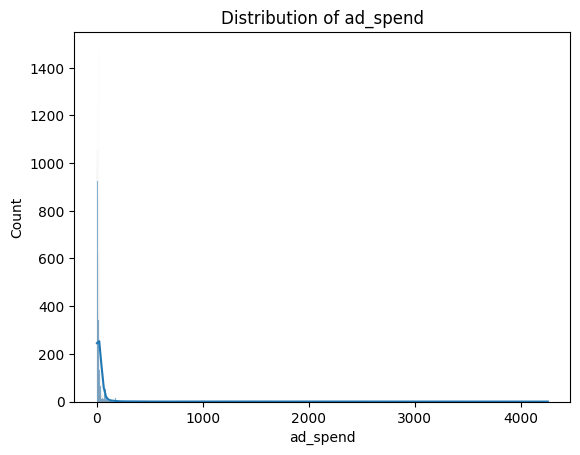

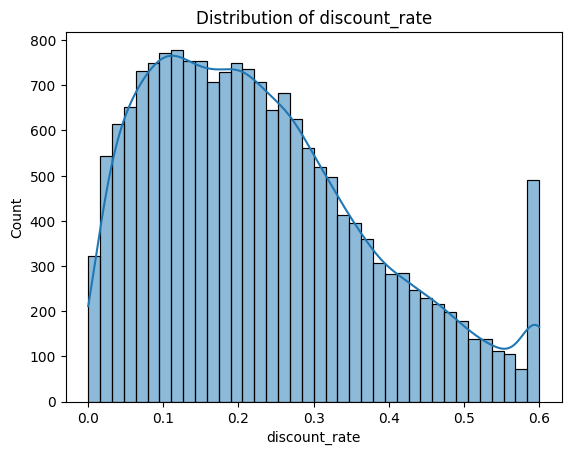

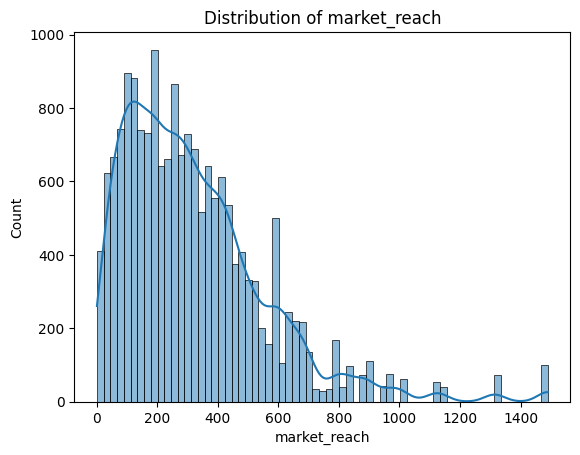

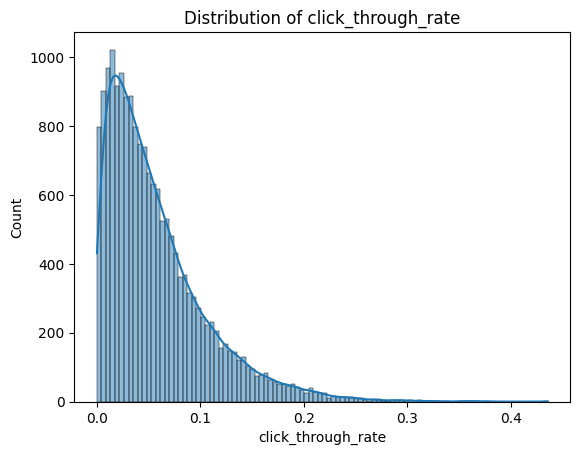

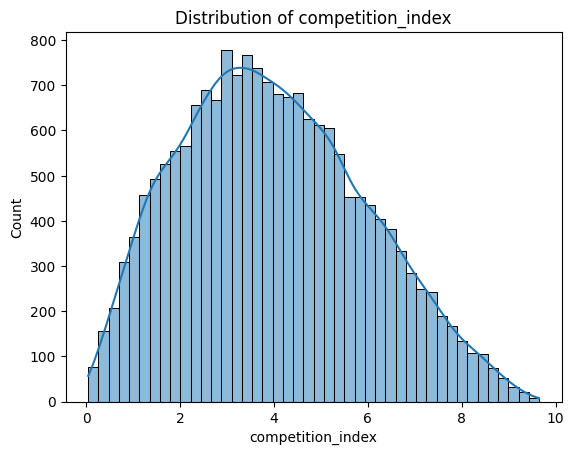

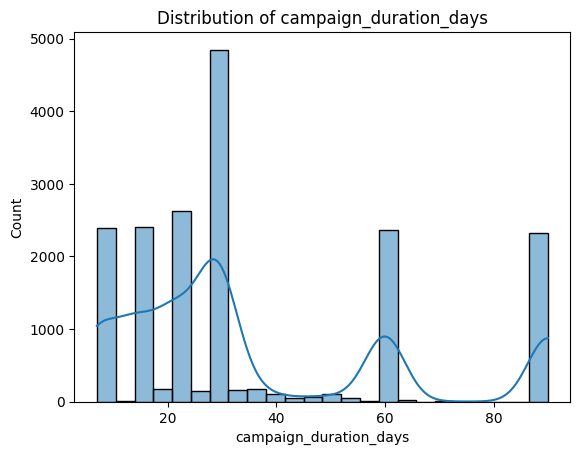

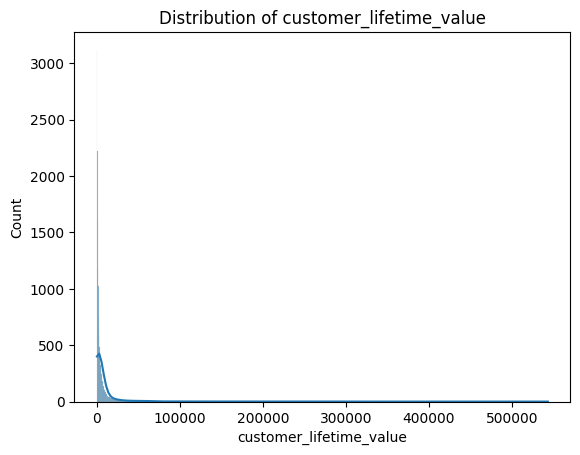

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

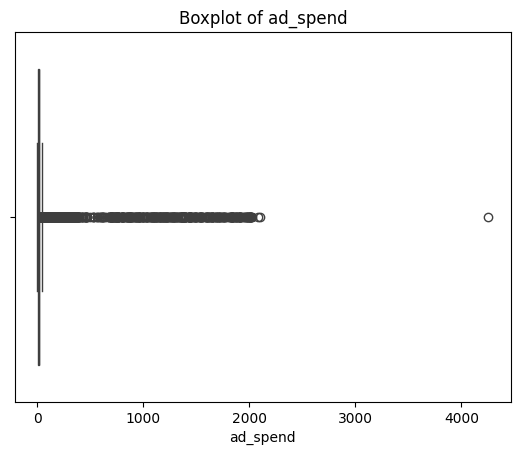

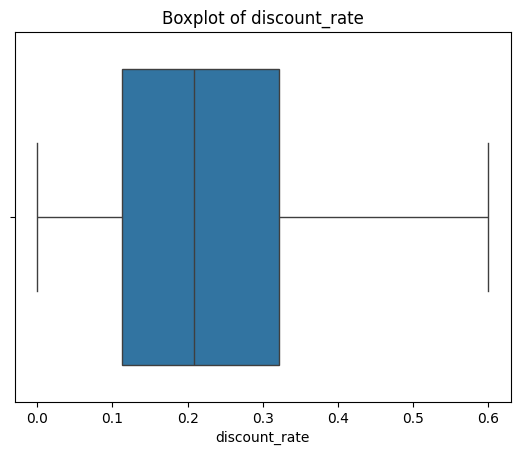

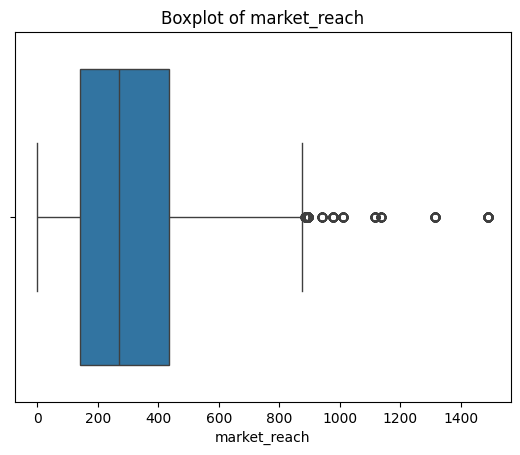

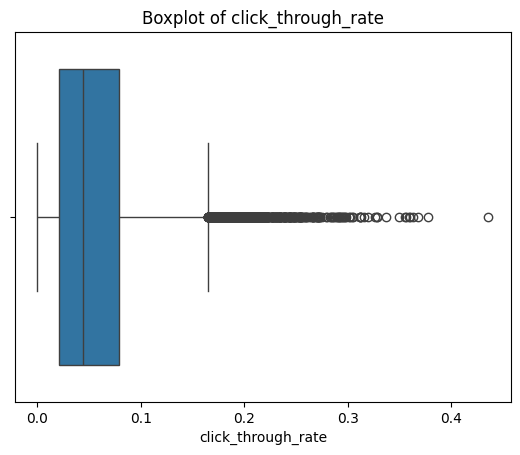

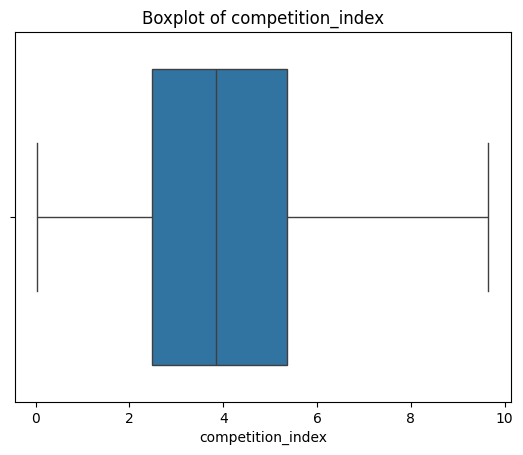

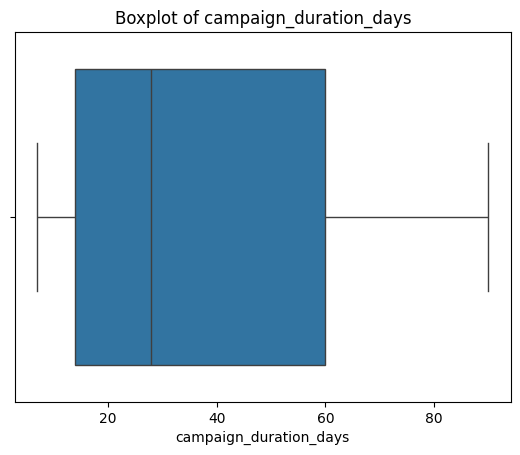

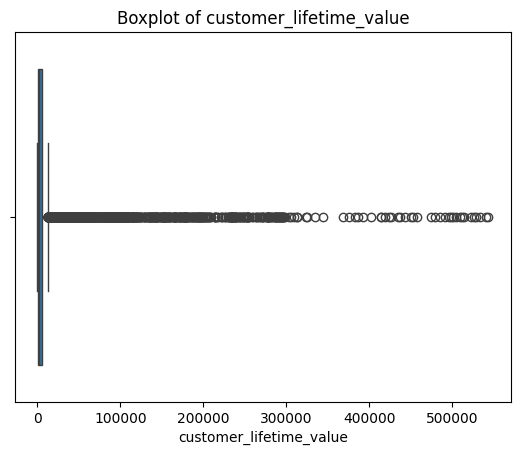

In [167]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [168]:
df[numerical_cols].skew()

,0
ad_spend,8.002793
discount_rate,0.655831
market_reach,1.533419
click_through_rate,1.569687
competition_index,0.301163
campaign_duration_days,1.036808
customer_lifetime_value,7.826731


In [170]:
df['ad_spend'] = df.groupby(group_cols)['ad_spend']\
                   .transform(lambda x: x.fillna(x.median()))

# Log transform
import numpy as np
df['ad_spend'] = np.log1p(df['ad_spend'])

In [171]:
df['customer_lifetime_value'] = df.groupby(group_cols)['customer_lifetime_value']\
    .transform(lambda x: x.fillna(x.median()))

df['customer_lifetime_value'] = np.log1p(df['customer_lifetime_value'])

In [172]:
for col in ['market_reach', 'click_through_rate']:
    df[col] = df.groupby(group_cols)[col]\
                .transform(lambda x: x.fillna(x.median()))

    df[col] = np.log1p(df[col])

In [173]:
df['discount_rate'] = df.groupby(group_cols)['discount_rate']\
                       .transform(lambda x: x.fillna(x.median()))

In [174]:
df['competition_index'].fillna(df['competition_index'].mean(), inplace=True)

/tmp/ipykernel_4442/2071247106.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['competition_index'].fillna(df['competition_index'].mean(), inplace=True)


In [ ]:
df['campaign_duration_days'].fillna(0, inplace=True)

/tmp/ipykernel_4442/3543375431.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['campaign_duration_days'].fillna(0, inplace=True)


In [175]:
def cap_outliers(col):
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

for col in numerical_cols:
    cap_outliers(col)

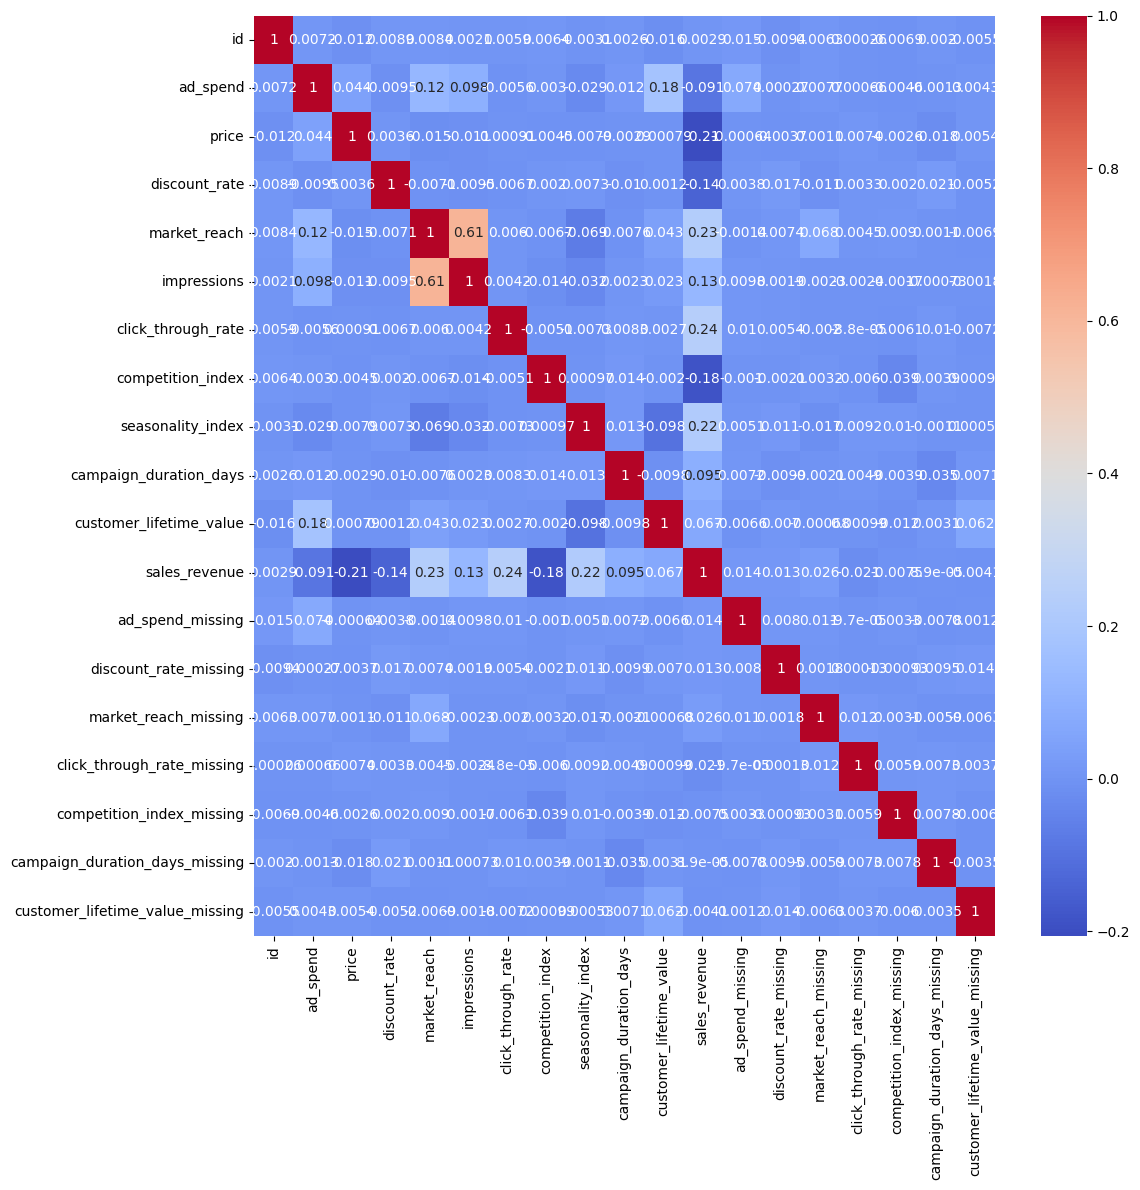

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))
sns.heatmap(df.corr(numeric_only =True), annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()

In [ ]:
# numeric_df = df.select_dtypes(include=['number'])
# numeric_df.corr()


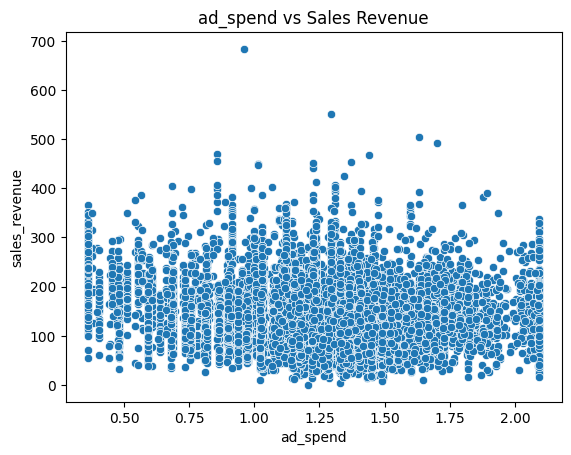

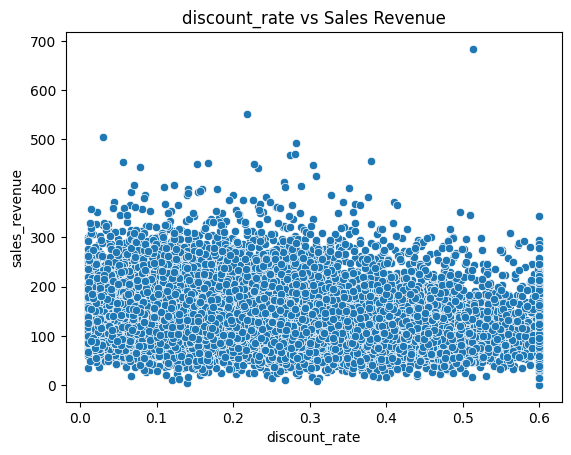

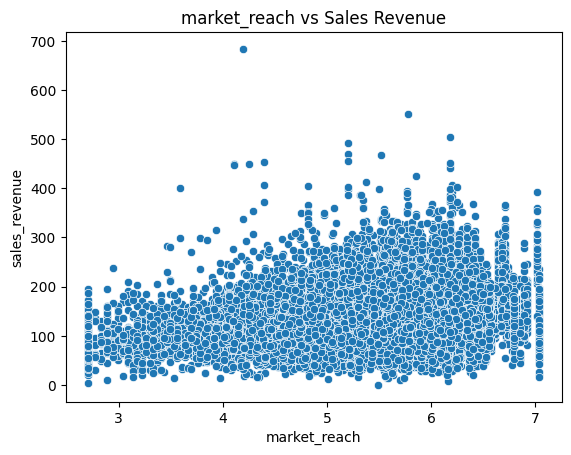

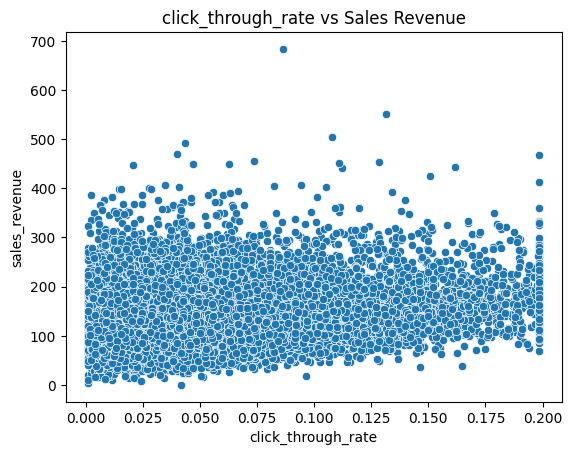

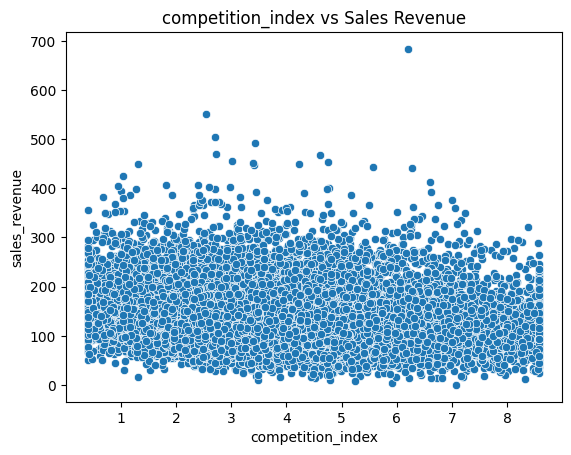

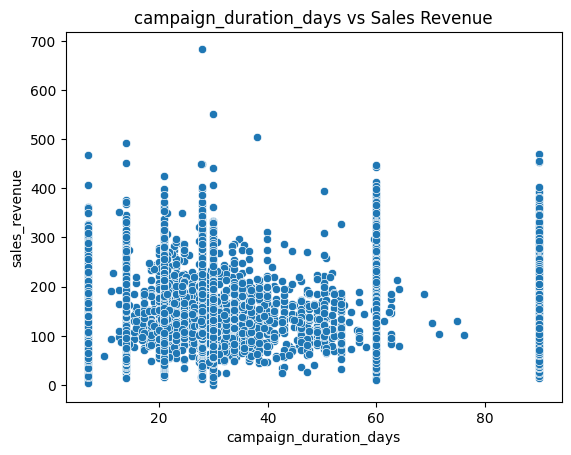

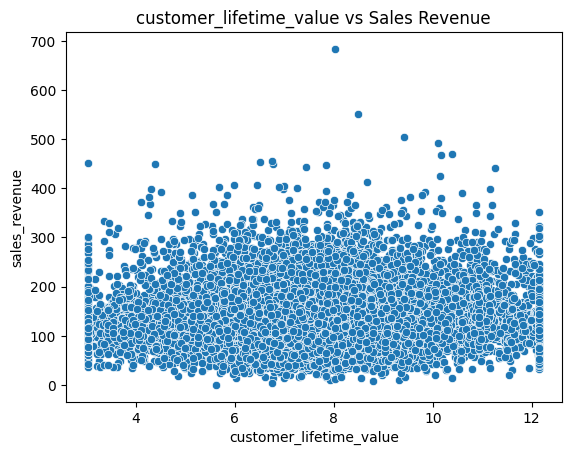

In [177]:
for col in numerical_cols:
    sns.scatterplot(x=df[col], y=df['sales_revenue'])
    plt.title(f'{col} vs Sales Revenue')
    plt.show()

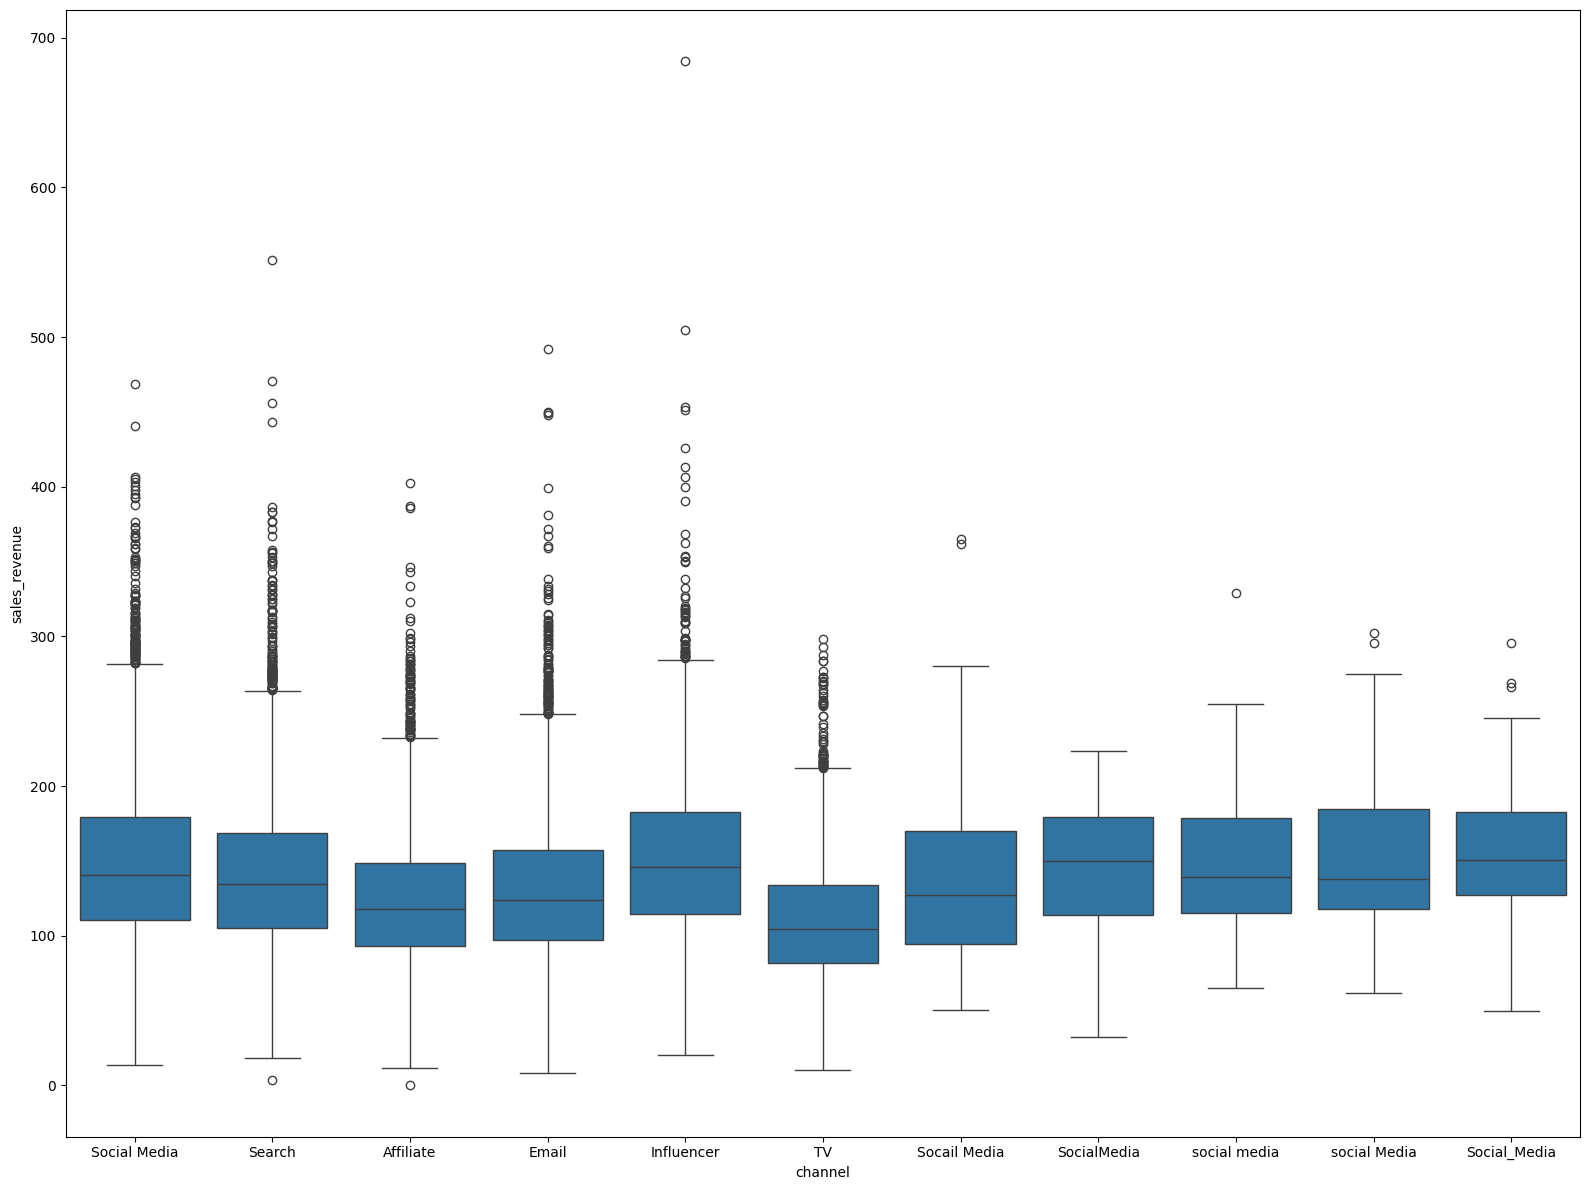

In [178]:
plt.figure(figsize=(16,12))  # ✅ first create figure

sns.boxplot(x='channel', y='sales_revenue', data=df)

# plt.xticks(rotation=20, ha='right', fontsize=8)  # improve readability
plt.tight_layout()
plt.show()

# sns.boxplot(x='customer_segment', y='sales_revenue', data=df)
# plt.figure(figsize=(16,14))
# plt.show()

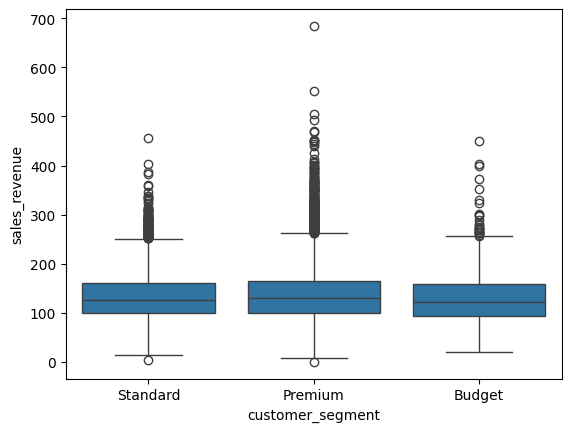

<Figure size 1600x1400 with 0 Axes>

In [179]:
sns.boxplot(x='customer_segment', y='sales_revenue', data=df)
plt.figure(figsize=(16,14))
plt.tight_layout()
plt.show()


In [180]:
import re
df['channel'] = df['channel'].str.lower().str.strip()
df['channel'] = df['channel'].replace(
    to_replace=r'.*social.*media.*',
    value='social_media',
    regex=True
)



In [181]:
df['channel'] = df['channel'].replace({
    r'.*email.*': 'email',
    r'.*search.*': 'search',
    r'.*affiliate.*': 'affiliate',
    r'.*tv.*': 'tv',
    r'.*influencer.*': 'influencer',
    r'.*socail.*media.*': 'social_media',
}, regex=True)

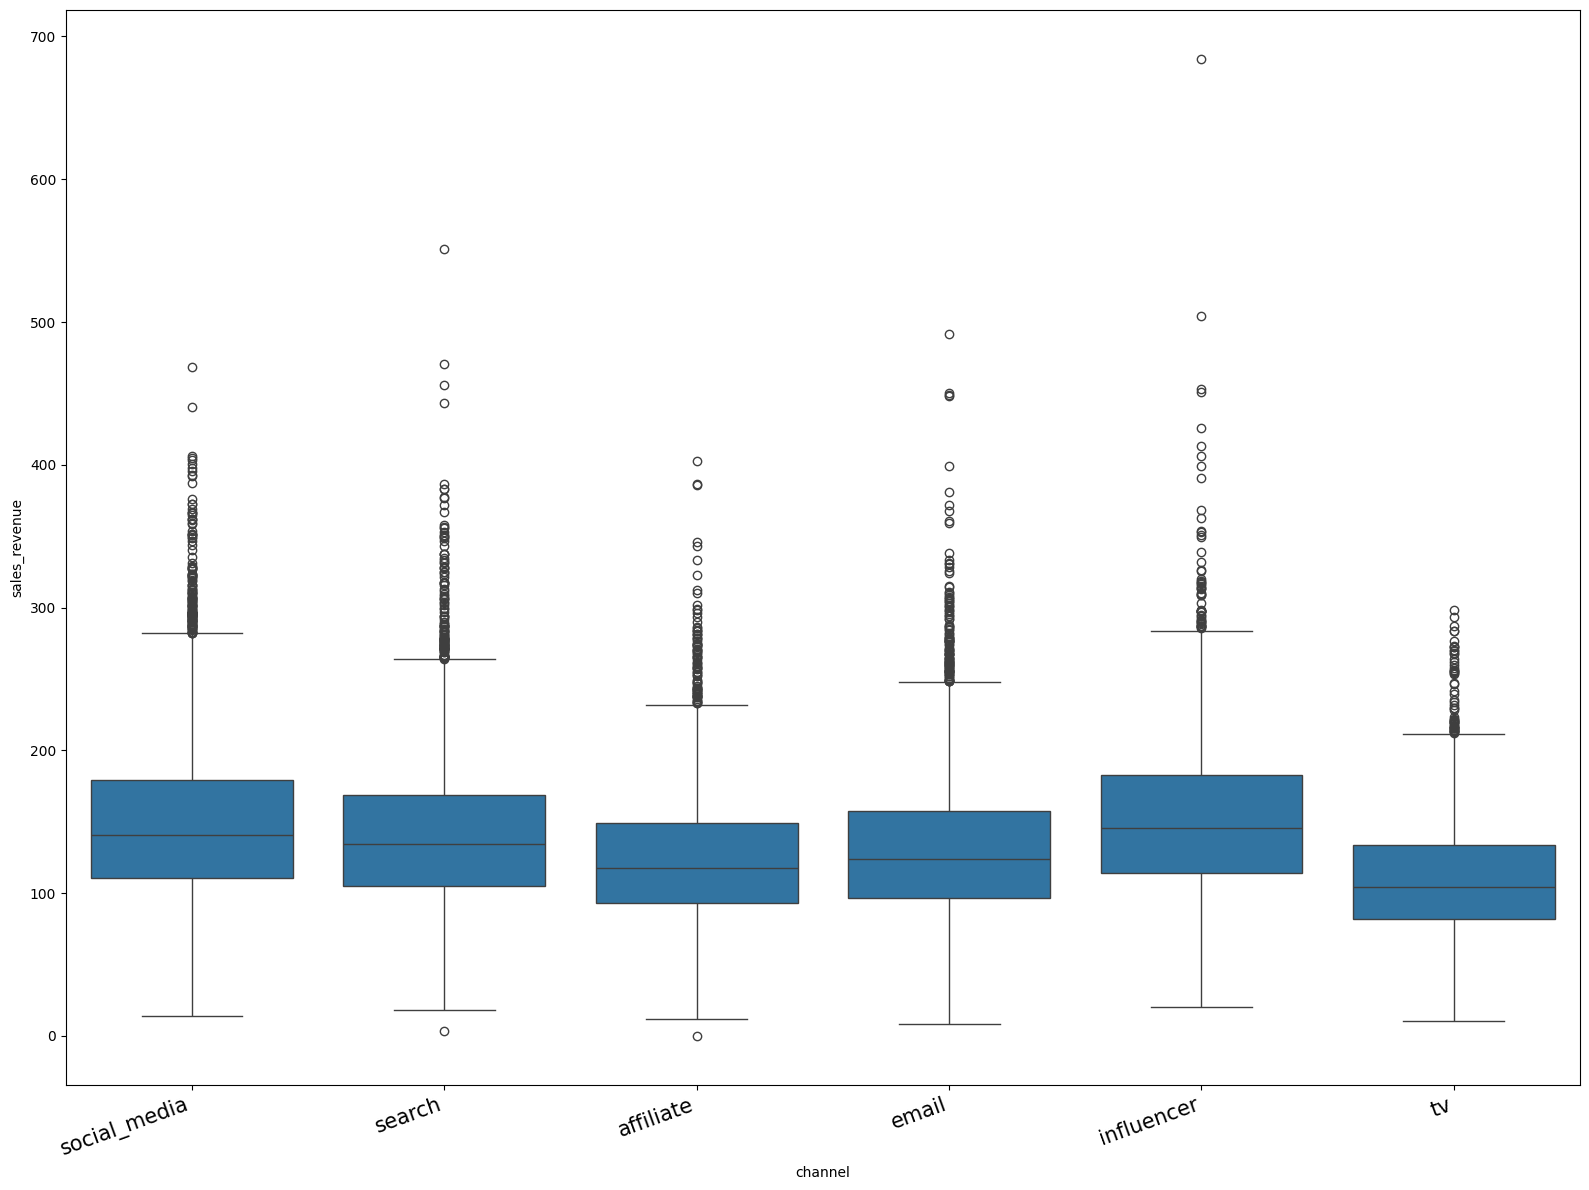

In [182]:
plt.figure(figsize=(16,12))  # ✅ first create figure

sns.boxplot(x='channel', y='sales_revenue', data=df)

plt.xticks(rotation=20, ha='right', fontsize=15)  # improve readability
plt.tight_layout()
plt.show()

In [183]:
df.columns

Index(['id', 'date', 'region', 'channel', 'product_category',
       'customer_segment', 'ad_spend', 'price', 'discount_rate',
       'market_reach', 'impressions', 'click_through_rate',
       'competition_index', 'seasonality_index', 'campaign_duration_days',
       'customer_lifetime_value', 'sales_revenue', 'ad_spend_missing',
       'discount_rate_missing', 'market_reach_missing',
       'click_through_rate_missing', 'competition_index_missing',
       'campaign_duration_days_missing', 'customer_lifetime_value_missing'],
      dtype='object')

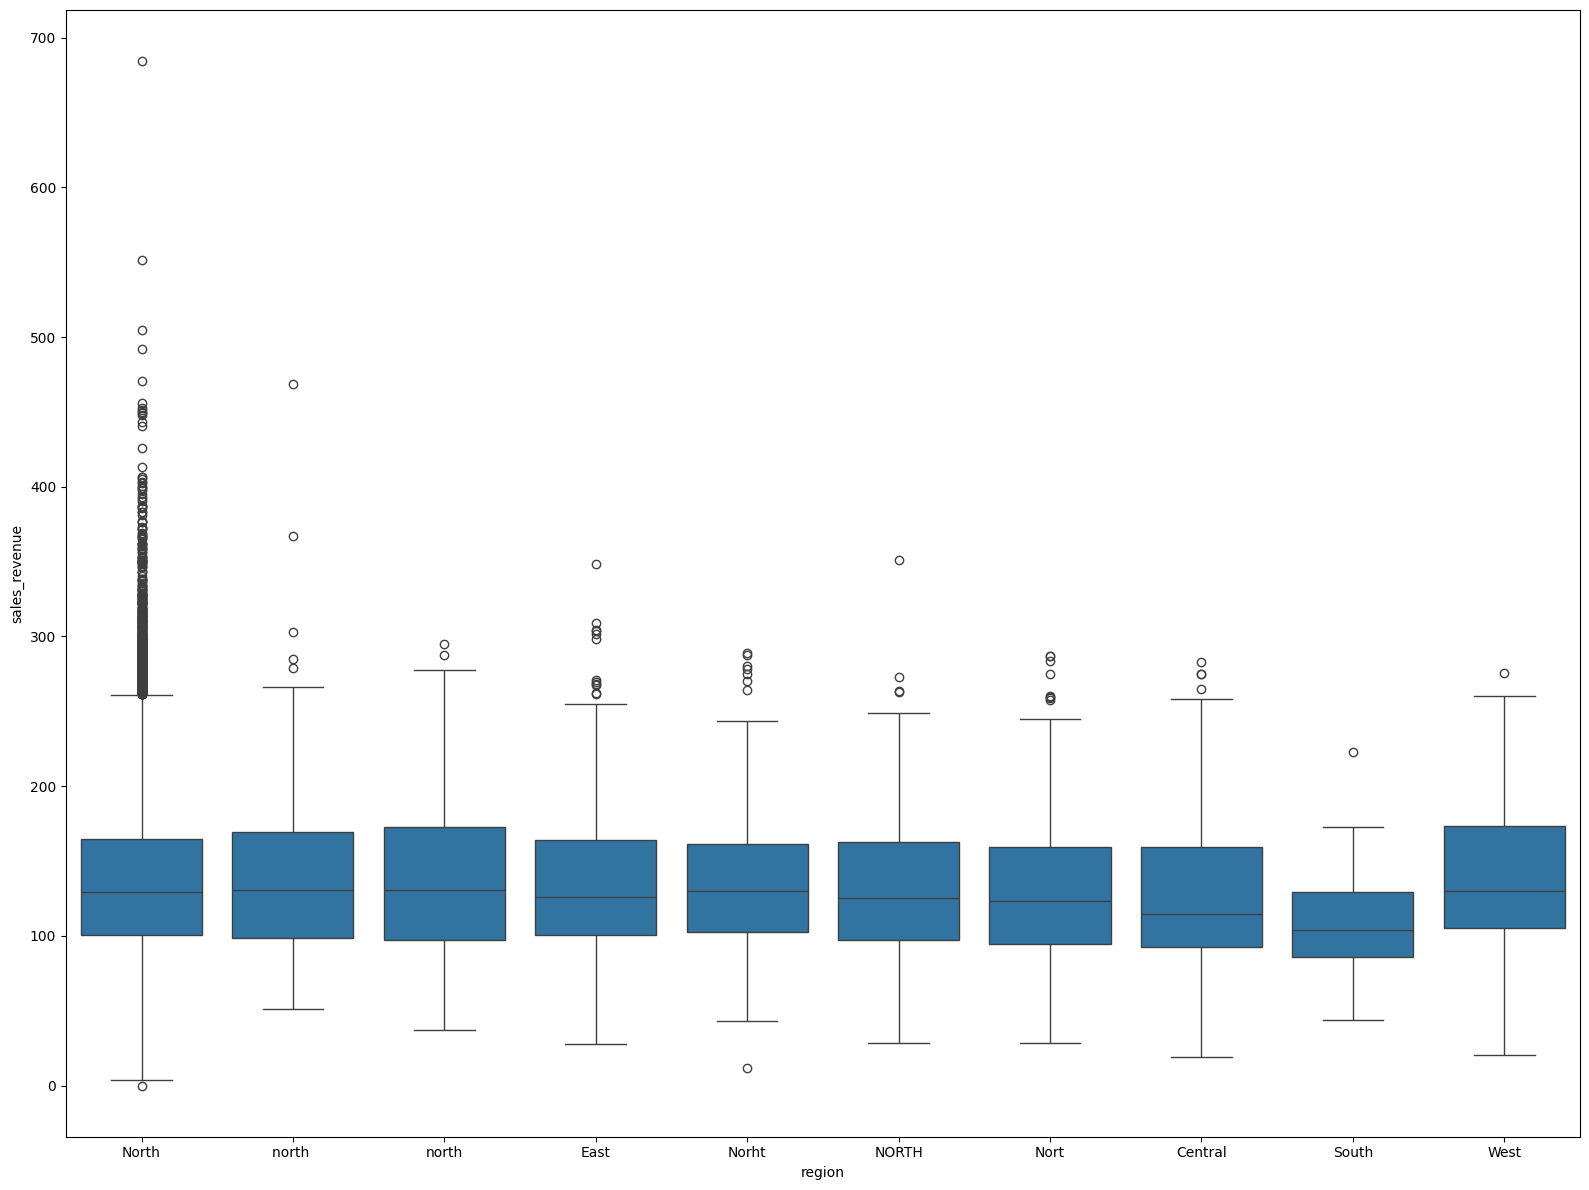

In [184]:
plt.figure(figsize=(16,12))  # ✅ first create figure

sns.boxplot(x='region', y='sales_revenue', data=df)
# plt.xticks(rotation=20, ha='right', fontsize=8)  # improve readability
plt.tight_layout()
plt.show()

In [185]:
df['region'] = df['region'].str.lower().str.strip()

In [186]:
df['region'] = df['region'].replace({
    r'.*nort*': 'north',
    r'.*norht*': 'north',
    r'.*northh*': 'north',
    r'.*northht*': 'north',
    r'.*northt*': 'north'
}, regex=True)

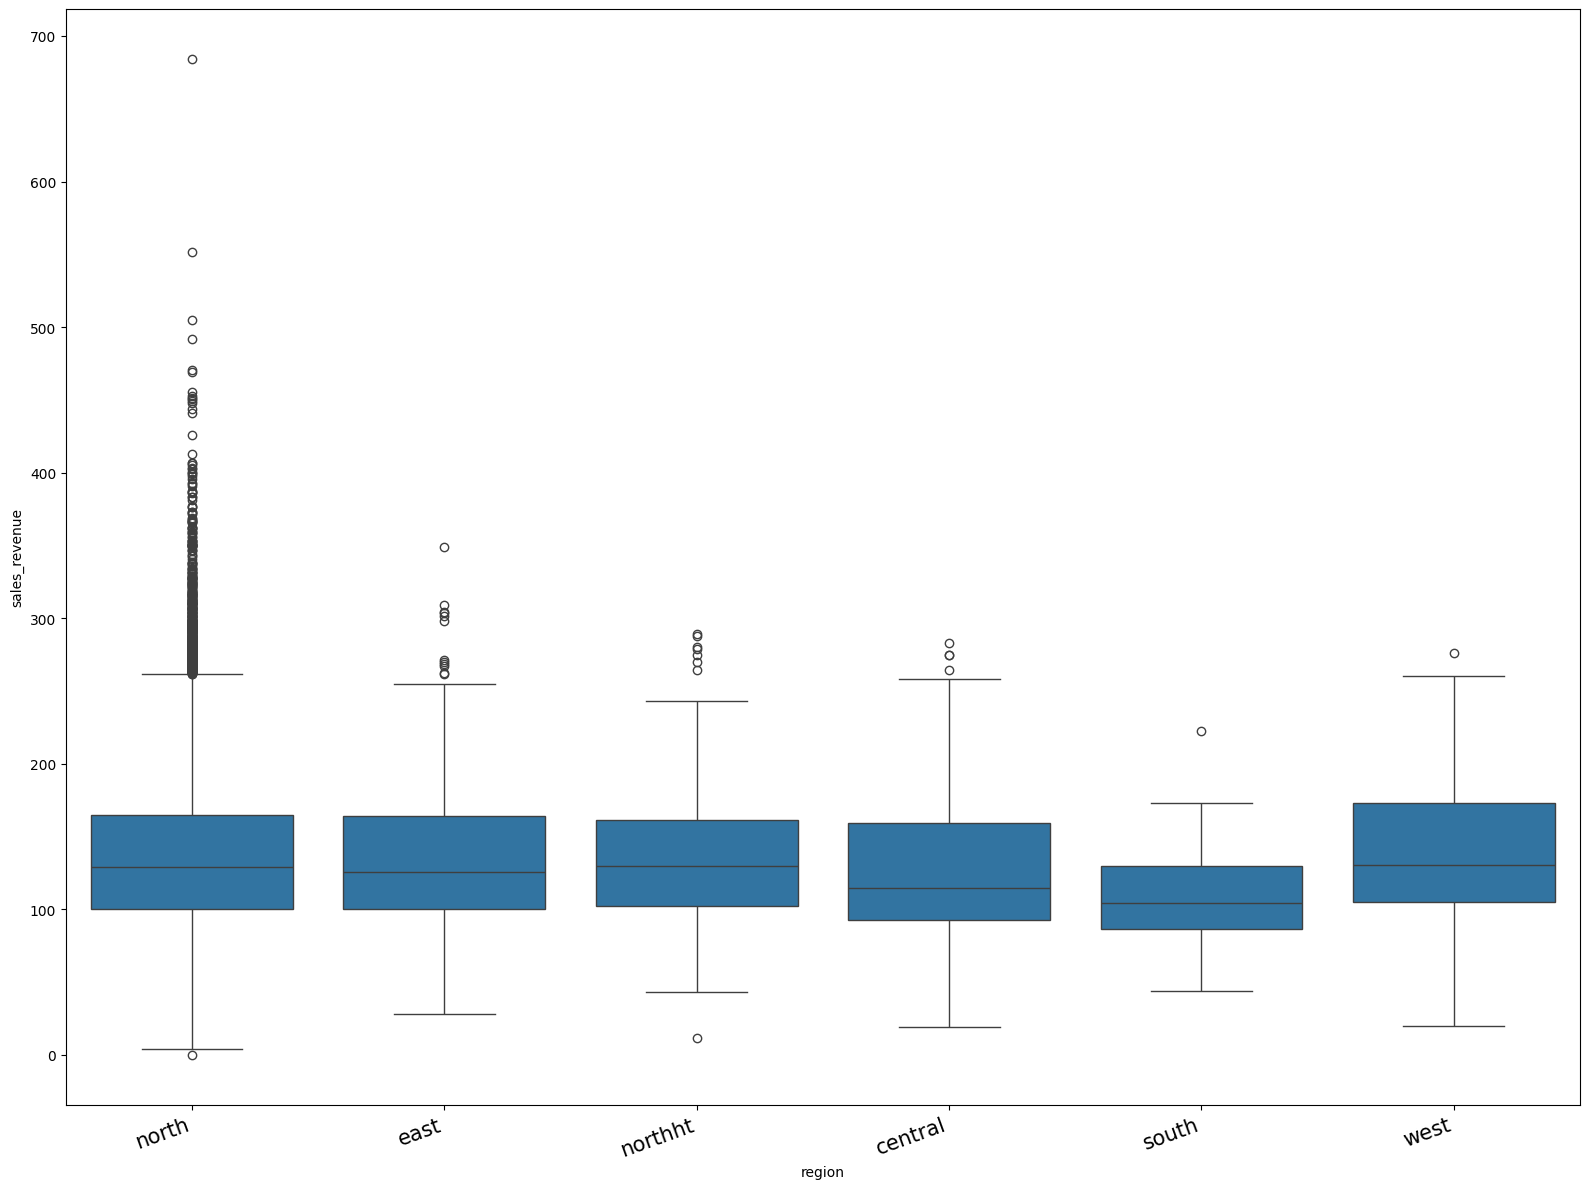

In [187]:
plt.figure(figsize=(16,12))  # ✅ first create figure

sns.boxplot(x='region', y='sales_revenue', data=df)
plt.xticks(rotation=20, ha='right', fontsize=15)  # improve readability
plt.tight_layout()
plt.show()

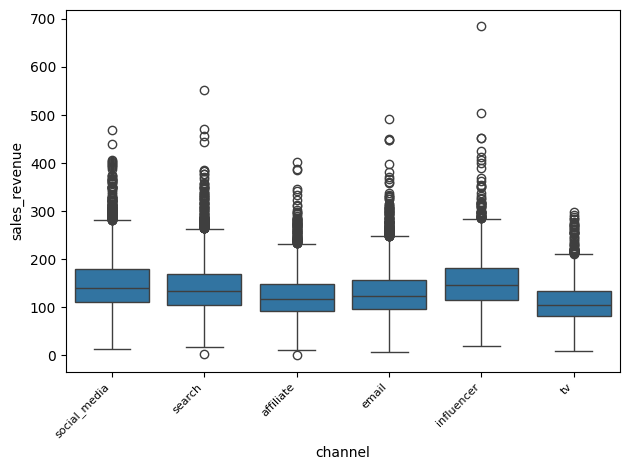

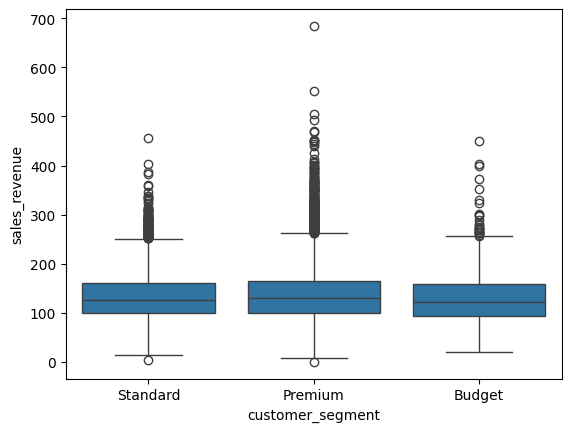

In [188]:
sns.boxplot(x='channel', y='sales_revenue', data=df)
plt.xticks(rotation=45, ha='right', fontsize=8)  # improve readability
plt.tight_layout()
plt.show()

sns.boxplot(x='customer_segment', y='sales_revenue', data=df)
plt.show()

In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

In [189]:
from sklearn.model_selection import train_test_split

X = df.drop('sales_revenue', axis=1)
y = df['sales_revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [190]:
# X = df.drop(['id', 'sales_revenue'], axis=1)

In [191]:
# X['date'] = pd.to_datetime(X['date'], format='mixed', dayfirst=True)

In [192]:
# # Extract features
# X['year'] = X['date'].dt.year
# X['month'] = X['date'].dt.month
# X['day'] = X['date'].dt.day

# # Drop original column
# X = X.drop('date', axis=1)

In [193]:
X = pd.get_dummies(X, drop_first=True)
X

,id,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,...,channel_search,channel_social_media,channel_tv,product_category_Kitchen,product_category_Lighting,product_category_Seasonal,product_category_Stationery,product_category_Storage,customer_segment_Premium,customer_segment_Standard
9257,9258,0.363431,0.550000,0.1591,5.777652,7123,0.036910,2.96,1.366025,28.0,...,False,True,False,True,False,False,False,False,False,True
5029,5030,1.261489,12.750000,0.1961,3.178054,881,0.155122,2.95,-1.366025,14.0,...,True,False,False,False,False,False,False,False,True,False
3097,3098,1.548364,1.650000,0.3548,6.056784,10271,0.032758,4.37,-1.366025,7.0,...,False,True,False,False,False,False,False,False,True,False
7880,7881,1.107951,0.550000,0.2479,6.298949,5974,0.084249,1.17,-1.366025,14.0,...,False,True,False,False,False,False,False,True,True,False
4436,4437,2.093148,2.080000,0.3474,4.564348,2064,0.076127,4.54,-1.000000,30.0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6880,6881,1.358505,203.829606,0.2953,5.541264,1558,0.062317,1.97,0.366025,7.0,...,False,True,False,False,False,False,False,False,True,False
1047,1048,1.449111,0.420000,0.2424,5.739793,3093,0.132694,0.66,1.366025,7.0,...,False,False,True,False,False,False,True,False,True,False
1646,1647,0.455279,0.390000,0.2476,5.068904,2319,0.055056,2.32,-1.366025,28.0,...,False,True,False,False,True,False,False,False,False,True
11469,11470,1.340611,3.950000,0.0108,5.978886,7604,0.132431,5.50,-0.366025,60.0,...,False,False,False,False,False,False,False,False,True,False


In [194]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [195]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
df.isnull().sum()

,0
id,0
date,0
region,0
channel,0
product_category,0
customer_segment,0
ad_spend,0
price,0
discount_rate,0
market_reach,0


In [201]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 40.456048559374096
MSE: 2785.1983758048386
RMSE: 52.77497869070947
R² Score: 0.04304894530577319


In [200]:
for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"K={k}, RMSE={np.sqrt(mean_squared_error(y_test, y_pred))}")

K=1, RMSE=64.17135887044768
K=2, RMSE=56.807147995876925
K=3, RMSE=54.83599755980977
K=4, RMSE=53.824952756654454
K=5, RMSE=53.6445604803931
K=6, RMSE=53.353113166484874
K=7, RMSE=53.3247852330274
K=8, RMSE=53.295472908356444
K=9, RMSE=53.47203538437118
K=10, RMSE=53.629822166768236
K=11, RMSE=53.76864755580939
K=12, RMSE=53.907307756766436
K=13, RMSE=53.99647014381118
K=14, RMSE=54.292602555210735
K=15, RMSE=54.06485965419024
K=16, RMSE=53.657810253838655
K=17, RMSE=53.28849148571311
K=18, RMSE=52.94771669972628
K=19, RMSE=52.82233892598223
K=20, RMSE=52.77497869070947


In [198]:
model = KNeighborsRegressor(n_neighbors=20)

ValueError: x and y must have same first dimension, but have shapes (20,) and (1,)

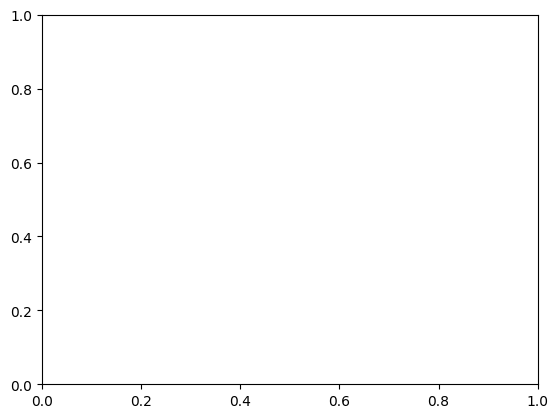

In [199]:
import matplotlib.pyplot as plt

k_values = range(1, 21)

plt.plot(k_values, rmse, marker='o')
plt.xlabel("K Value")
plt.ylabel("RMSE")
plt.title("K vs RMSE")
plt.show()